# Check the High Level sliced wasserstein distances

Compare to the validation loss of the corrisponding checkpoint.

In [1]:
import glob
import numpy as np
from matplotlib import pyplot as plt
import yaml
import os
from src.evaluation import plotting
from plotting_rules import colours, pretty_names
from src.training.best_checkpoint import checkpoint_scores

In [2]:
n_projections = 1000
paths = glob.glob(f"/data/dust/user/dayhallh/data/CaloClouds_diffusion/logs/*/checkpoints/*_slicedHLwas{n_projections}.npz")
print(f"Found {len(paths)} distances")
log_dirs = []
tags = []
distances = []
distances_by_pdg = {-11:[], 11:[], 22:[]}
errors_by_pdg = {-11:[], 11:[], 22:[]}
errors = []
val_loss = []
was_tag = f"_slicedHLwas{n_projections}.npz"
for path in paths:
    log_dir = os.path.dirname(os.path.dirname(path))
    checkpoints = checkpoint_scores(log_dir)
    assert was_tag in path
    model_name = path.replace(was_tag, ".pt")
    for ckpt in checkpoints:
        if ckpt['path'] == model_name:
            val_loss.append(ckpt['value'])
            break
    else:
        val_loss.append(None)
        print(f"Didn't find {model_name}")
        
    log_dirs.append(log_dir)
    tag = os.path.basename(glob.glob(os.path.join(log_dir, "_a_*"))[0])[3:].replace("_", " ")
    print(tag)
    tags.append(tag)
    
    with open(path, 'r') as f:
        result = yaml.safe_load(f)
    distances.append(result["distance"])
    errors.append(result["error"])
    if "pdg_22_distance" in result:
        for pdg in distances_by_pdg:
            distances_by_pdg[pdg].append(result[f"pdg_{pdg}_distance"])
            errors_by_pdg[pdg].append(result[f"pdg_{pdg}_error"])
    else:
        distances_by_pdg[22].append(result["distance"])
        errors_by_pdg[22].append(result["error"])
        distances_by_pdg[-11].append(None)
        errors_by_pdg[-11].append(None)
        distances_by_pdg[11].append(None)
        errors_by_pdg[11].append(None)

Found 8 distances
generalist and moe all
only moe all
padded photons v2
distill of padded photons v1
only mos all
distilled 2 from padded photons v1
padded all v1
generalist and mos all


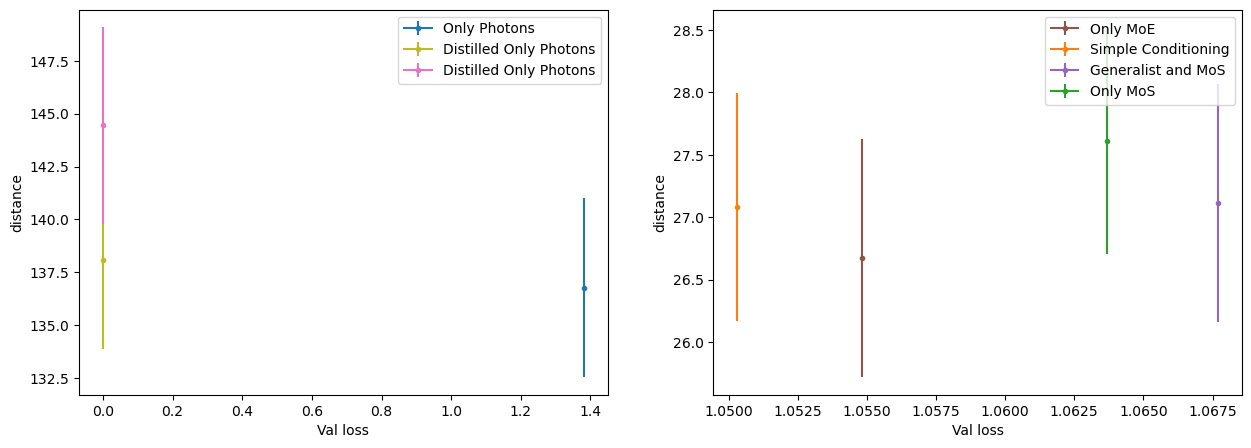

In [3]:
fig, axarr = plt.subplots(1, 2, figsize=(15, 5))

order = np.argsort(distances)
for i in order:
    tag = tags[i]
    
    c = colours[tag]
    pretty = pretty_names[tag]
    if "Generalist and MoE" in pretty:
        continue
    if "Photons" in pretty:
        ax = axarr[0]
    else:
        ax = axarr[1]
    
    ax.errorbar([val_loss[i]], [distances[i]], [errors[i]], c=c, marker='.', label=pretty_names[tag])
for ax in axarr:
    ax.legend()
    ax.set_xlabel("Val loss")
    ax.set_ylabel("distance")

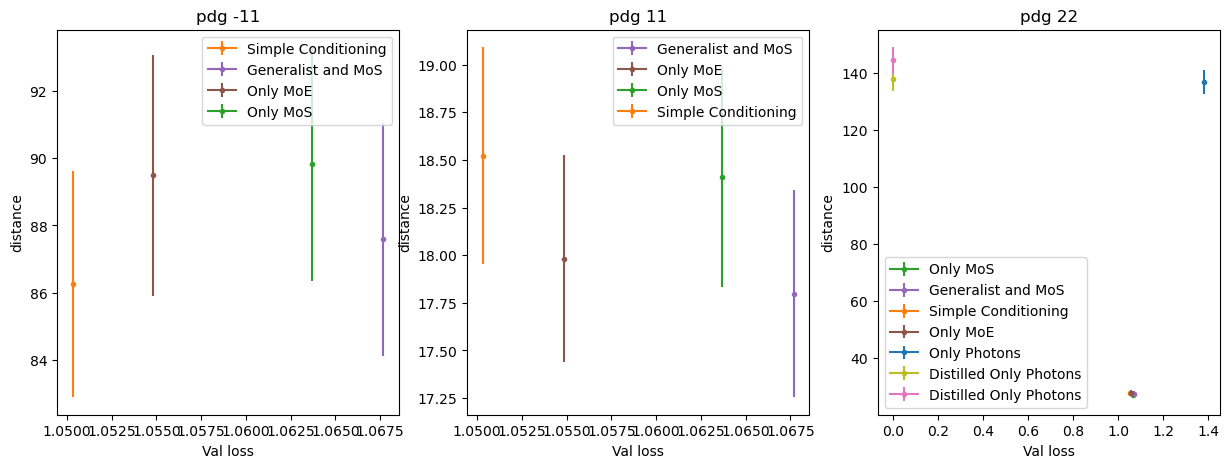

In [4]:
fig, axarr = plt.subplots(1, 3, figsize=(15, 5))

for i, pdg in enumerate(distances_by_pdg.keys()):
    ax = axarr[i]
    ax.set_title(f"pdg {pdg}")
    sanitised_distances = [0 if d is None else d for d in distances_by_pdg[pdg]]
    order = np.argsort(sanitised_distances)
    for i in order:
        dist = distances_by_pdg[pdg][i]
        if dist is None:
            continue
        tag = tags[i]
        c = colours[tag]
        pretty = pretty_names[tag]
        if "Generalist and MoE" in pretty:
            continue
        ax.errorbar([val_loss[i]], [dist], [errors_by_pdg[pdg][i]], c=c, marker='.', label=pretty_names[tag])
    ax.legend()
    ax.set_xlabel("Val loss")
    ax.set_ylabel("distance")

In [12]:
sanitised_distances

array([96.84108685265149, 87.27061365162398, None, None,
       94.97619866332026, None, 96.42333347656823, 87.01471532089981],
      dtype=object)